# 📧 Email Spam Classification — End-to-End NLP Pipeline

**Dataset:** SpamAssassin (5,796 emails — 3,900 ham / 1,896 spam)

### Key Design Decisions
| Concern | Solution |
|---|---|
| **Data Leakage** | Train/test split BEFORE any feature fitting; `Pipeline` enforces fit-on-train-only |
| **Overfitting** | StratifiedKFold CV, regularisation, learning curves, hold-out test set |
| **Class Imbalance** | `class_weight='balanced'` + stratified splits |

### Table of Contents
1. [Imports & Setup](#1)
2. [Load & Explore Data (EDA)](#2)
3. [Text Preprocessing](#3)
4. [Train / Test Split — NO LEAKAGE](#4)
5. [Feature Engineering with TF-IDF (inside Pipeline)](#5)
6. [Model Training + Cross-Validation](#6)
7. [Hyperparameter Tuning](#7)
8. [Learning Curves — Overfitting Check](#8)
9. [Final Evaluation on Hold-Out Test Set](#9)
10. [Feature Importance / Top Spam Keywords](#10)
11. [Summary](#11)

---
## 1. Imports & Setup <a id='1'></a>

In [2]:
# ── Core ──────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
from email import message_from_string
from scipy.sparse import hstack, csr_matrix
import mlflow


import sys
sys.path.append("/Users/kaushikchariya/Deep-Shield-Mail")

import mlflow.sklearn

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── NLP ───────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

# ── ML ────────────────────────────────────────────────────────────
from sklearn.pipeline          import Pipeline
from sklearn.model_selection   import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    GridSearchCV,
)
from sklearn.linear_model      import LogisticRegression
from sklearn.naive_bayes       import MultinomialNB
from sklearn.svm               import LinearSVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from sklearn.calibration       import CalibratedClassifierCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('All imports successful ✅')

/opt/anaconda3/envs/spamdetector/lib/python3.10/site-packages/pydantic/_internal/_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


All imports successful ✅


---
## 2. Load & Explore Data (EDA) <a id='2'></a>

In [3]:
df = pd.read_csv('../data/spam_assassin.csv')

print('Shape      :', df.shape)
print('Columns    :', df.columns.tolist())
print('Null values:\n', df.isnull().sum())
print()
df.head(3)

Shape      : (5796, 2)
Columns    : ['text', 'target']
Null values:
 text      0
target    0
dtype: int64



,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1


label
Ham (legitimate)    3900
Spam                1896
Name: count, dtype: int64


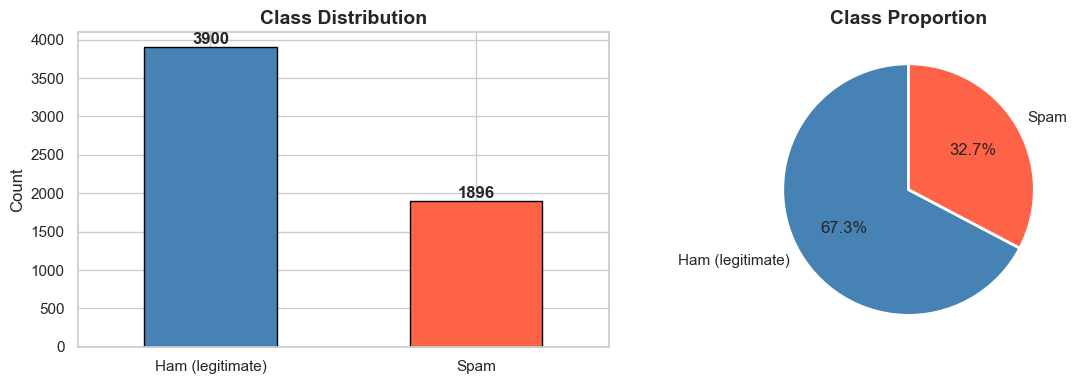


⚠️  Imbalanced dataset — using stratified splits + class_weight="balanced"


In [4]:
# ── Label distribution ────────────────────────────────────────────
label_map  = {0: 'Ham (legitimate)', 1: 'Spam'}
df['label'] = df['target'].map(label_map)

counts = df['label'].value_counts()
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n⚠️  Imbalanced dataset — using stratified splits + class_weight="balanced"')

                 char_count                                                 \
                      count    mean     std    min     25%     50%     75%   
label                                                                        
Ham (legitimate)     3900.0  3483.1  3134.1  362.0  2435.2  3196.5  4049.2   
Spam                 1896.0  5667.1  9068.5  736.0  2391.8  3824.0  6304.0   

                           word_count                                    \
                       max      count   mean    std   min    25%    50%   
label                                                                     
Ham (legitimate)   92469.0     3900.0  405.7  484.9  45.0  262.0  347.0   
Spam              232305.0     1896.0  545.6  612.2  73.0  250.0  386.0   

                                  
                    75%      max  
label                             
Ham (legitimate)  454.0  15164.0  
Spam              617.2  11857.0  


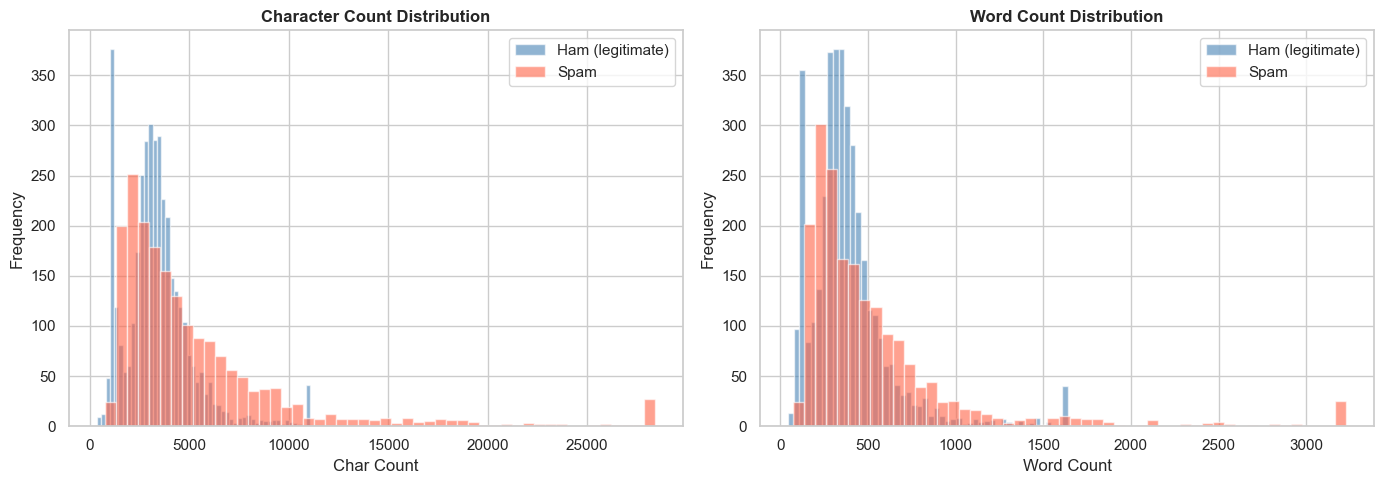

In [5]:
# ── Email length analysis ─────────────────────────────────────────
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(df.groupby('label')[['char_count', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['char_count', 'word_count'],
                           ['Character Count Distribution', 'Word Count Distribution']):
    for label, color in [('Ham (legitimate)', 'steelblue'), ('Spam', 'tomato')]:
        subset = df[df['label'] == label][col]
        subset.clip(upper=subset.quantile(0.99)).plot(
            kind='hist', bins=50, ax=ax, alpha=0.6,
            color=color, label=label, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.savefig('02_length_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Text Preprocessing <a id='3'></a>

> **No fitting happens here** — this is purely rule-based cleaning (regex). Fitting (TF-IDF vocab) happens only inside the Pipeline on training data.

In [6]:
def preprocess_email(text: str) -> str:
    """
    Rule-based (stateless) email cleaning.
    Safe to apply to full dataset BEFORE split — no statistics are learned.
    """
    if not isinstance(text, str):
        return ''
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove email headers (lines like 'From:', 'Subject:', 'Received:')
    text = re.sub(r'^(from|subject|to|cc|bcc|received|content-type|mime-version|'  
                  r'message-id|return-path|delivered-to|x-[a-z-]+):.*$',
                  '', text, flags=re.MULTILINE | re.IGNORECASE)
    
    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    
    # 4. Replace email addresses
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.-]+', ' email ', text)
    
    # 5. Replace currency amounts
    text = re.sub(r'\$\s*\d+[\d,\.]*', ' money ', text)
    
    # 6. Replace phone numbers
    text = re.sub(r'\b(\+?\d[\s.-]?){7,15}\b', ' phone ', text)
    
    # 7. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # 8. Remove special characters and digits (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 9. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Apply stateless cleaning to full dataset (no leakage risk)
df['clean_text'] = df['text'].apply(preprocess_email)

# Sanity check
print('Original:')
print(df['text'].iloc[1][:300])
print()
print('Cleaned:')
print(df['clean_text'].iloc[1][:300])

Original:
From gort44@excite.com Mon Jun 24 17:54:21 2002 Return-Path: gort44@excite.com Delivery-Date: Tue Jun 4 05:31:16 2002 Received: from mandark.labs.netnoteinc.com ([213.105.180.140]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g544VFO20182 for <jm@jmason.org>; Tue, 4 Jun 2002 05:31:15 +0100 R

Cleaned:
from email mon jun return path email delivery date tue jun received from mandark labs netnoteinc com phone by dogma slashnull org with esmtp id g vfo for tue jun received from wi poli poli cl phone by mandark labs netnoteinc com with smtp id g vc tue jun received from phone unverified phone by wi po


In [7]:
# ── Basic NLP stats after cleaning ───────────────────────────────
df['clean_word_count'] = df['clean_text'].str.split().str.len()

print('Stats after cleaning:')
print(df.groupby('label')['clean_word_count'].describe().round(1))

# Drop helper columns before modelling
df.drop(columns=['char_count', 'word_count', 'clean_word_count', 'label'], inplace=True)

Stats after cleaning:
                   count   mean     std  min    25%    50%    75%      max
label                                                                     
Ham (legitimate)  3900.0  367.0   458.8  0.0  236.0  324.0  426.0  14744.0
Spam              1896.0  442.8  1106.2  0.0  187.8  274.0  433.0  29041.0


---
## 4. Train / Test Split — NO DATA LEAKAGE <a id='4'></a>

> ⚠️ **Critical leakage prevention rule:** The test set is held out NOW and never seen again until final evaluation. TF-IDF vocabulary and IDF weights are computed ONLY on `X_train` (inside the Pipeline).

In [8]:
X = df['clean_text']
y = df['target']

# Stratified split preserves class ratios in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y          # ← preserves imbalance ratio
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print()
print('Train class distribution:')
print(y_train.value_counts(normalize=True).rename({0:'Ham', 1:'Spam'}).map('{:.1%}'.format))
print()
print('Test class distribution:')
print(y_test.value_counts(normalize=True).rename({0:'Ham', 1:'Spam'}).map('{:.1%}'.format))
print()
print('✅ Test set locked away — will not be touched until Section 9')

Training set : 4636 samples
Test set     : 1160 samples

Train class distribution:
target
Ham     67.3%
Spam    32.7%
Name: proportion, dtype: object

Test class distribution:
target
Ham     67.3%
Spam    32.7%
Name: proportion, dtype: object

✅ Test set locked away — will not be touched until Section 9


---
## 5. Feature Engineering with TF-IDF (inside Pipeline) <a id='5'></a>

Wrapping TF-IDF inside `Pipeline` **guarantees**:
- `.fit()` → learns vocab/IDF from **training data only**
- `.transform()` → applies learned vocab to test data (no fitting)

This is the standard way to prevent leakage in sklearn.

In [9]:
# ── TF-IDF configuration ──────────────────────────────────────────
# stop_words='english' uses sklearn's built-in list (no NLTK needed)
# sublinear_tf=True dampens term frequency (reduces impact of repetition)
# max_features limits vocab size → regularisation effect

TFIDF_PARAMS = dict(
    analyzer     = 'word',
    ngram_range  = (1, 2),       # unigrams + bigrams
    stop_words   = 'english',    # remove English stop words
    sublinear_tf = True,         # apply log(1+tf) instead of raw tf
    max_features = 30_000,       # vocabulary cap → prevents feature explosion
    min_df       = 3,            # ignore very rare terms → noise reduction
    max_df       = 0.90,         # ignore near-universal terms
    strip_accents= 'unicode',
)

print('TF-IDF config ready ✅')
print('ngram_range=(1,2) captures phrases like "click here", "free money"')

TF-IDF config ready ✅
ngram_range=(1,2) captures phrases like "click here", "free money"


In [10]:
import dagshub

mlflow.set_tracking_uri('https://dagshub.com/kaushik-chariya/Deep-Shield-Mail.mlflow')
dagshub.init(repo_owner='kaushik-chariya', repo_name='Deep-Shield-Mail', mlflow=True)


mlflow.set_experiment("All-Spam-Detection-HyperParamater")

Accessing as kaushik-chariya

Initialized MLflow to track repo "kaushik-chariya/Deep-Shield-Mail"

Repository kaushik-chariya/Deep-Shield-Mail initialized!

<Experiment: artifact_location='mlflow-artifacts:/1cc14b2da5d94c57938ab90596402405', creation_time=1779060867749, experiment_id='16', last_update_time=1779060867749, lifecycle_stage='active', name='All-Spam-Detection-HyperParamater', tags={}>

---
## 6. Model Training + Cross-Validation <a id='6'></a>

We evaluate 4 classifiers with **5-fold Stratified Cross-Validation** on the training set.
The test set is still locked.

In [11]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)



# ─── scale_pos_weight ─────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight : {scale_pos_weight:.2f}')

# ─── Model zoo ────────────────────────────────────────────────────
models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   MultinomialNB(alpha=0.1)),
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(
            C=1.0, max_iter=1000,
            class_weight='balanced',
            solver='lbfgs', random_state=SEED,
        )),
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   CalibratedClassifierCV(
            LinearSVC(C=0.5, max_iter=2000,
                      class_weight='balanced', random_state=SEED)
        )),
    ]),
    'Decision Tree': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   DecisionTreeClassifier(
            max_depth=20, min_samples_leaf=5,
            class_weight='balanced', random_state=SEED,
        )),
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   RandomForestClassifier(
            n_estimators=200, max_depth=20, min_samples_leaf=5,
            class_weight='balanced', n_jobs=-1, random_state=SEED,
        )),
    ]),
    'XGBoost': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss', n_jobs=-1, random_state=SEED,
        )),
    ]),
}
print(f'{len(models)} models defined ✅')

# ─── CV + MLflow logging ───────────────────────────────────────────
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}   # summary table

for model_name, pipeline in models.items():
    print(f'\n▶ Training : {model_name}')

    with mlflow.start_run(run_name=model_name):

        # ── tags ──────────────────────────────────────────────────
        mlflow.set_tags({
            'model'    : model_name,
            'stage'    : 'model-zoo-cv',
            'dataset'  : 'SpamAssassin',
        })

        # ── log hyper-params of the classifier ────────────────────
        clf_params = pipeline.named_steps['clf'].get_params()
        mlflow.log_params(clf_params)
        mlflow.log_params({                  # shared feature params
            'tfidf_ngram_range' : str(TFIDF_PARAMS['ngram_range']),
            'tfidf_max_features': TFIDF_PARAMS['max_features'],
            'tfidf_min_df'      : TFIDF_PARAMS['min_df'],
            'tfidf_sublinear_tf': TFIDF_PARAMS['sublinear_tf'],
            'cv_folds'          : 5,
            'train_size'        : len(y_train),
        })

        # ── 5-fold CV ─────────────────────────────────────────────
        cv_scores = cross_validate(
            pipeline,
            X_train, y_train,
            cv=skf,
            scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
            return_train_score=True,
            n_jobs=1,
        )

        cv_metrics = {
            'cv_accuracy'  : cv_scores['test_accuracy'].mean(),
            'cv_f1'        : cv_scores['test_f1'].mean(),
            'cv_precision' : cv_scores['test_precision'].mean(),
            'cv_recall'    : cv_scores['test_recall'].mean(),
            'cv_auc_roc'   : cv_scores['test_roc_auc'].mean(),
            'cv_f1_std'    : cv_scores['test_f1'].std(),
            'cv_train_f1'  : cv_scores['train_f1'].mean(),
            'cv_overfit_gap': (cv_scores['train_f1'].mean()
                               - cv_scores['test_f1'].mean()),
        }
        mlflow.log_metrics(cv_metrics)

        # ── fit final model on full train set ─────────────────────
        pipeline.fit(X_train, y_train)
        y_pred      = pipeline.predict(X_test)
        y_pred_prob = (pipeline.predict_proba(X_test)[:, 1]
                       if hasattr(pipeline, 'predict_proba')
                       else None)

        test_metrics = {
            'test_accuracy'  : accuracy_score(y_test, y_pred),
            'test_f1'        : f1_score(y_test, y_pred),
            'test_precision' : precision_score(y_test, y_pred),
            'test_recall'    : recall_score(y_test, y_pred),
        }
        if y_pred_prob is not None:
            test_metrics['test_auc_roc'] = roc_auc_score(y_test, y_pred_prob)

        mlflow.log_metrics(test_metrics)

        # ── log model artifact ────────────────────────────────────
        signature = infer_signature(X_train, pipeline.predict(X_train))
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path=f"model_{model_name.lower().replace(' ', '_')}",
            signature=signature,
            registered_model_name=f"spam_{model_name.lower().replace(' ', '_')}",
        )

        # ── print summary ─────────────────────────────────────────
        results[model_name] = {**cv_metrics, **test_metrics}
        print(f'   CV  F1 : {cv_metrics["cv_f1"]:.4f} ± {cv_metrics["cv_f1_std"]:.4f}')
        print(f'   Test F1: {test_metrics["test_f1"]:.4f}')
        print(f'   Overfit: {cv_metrics["cv_overfit_gap"]:.4f}')
        print(f'   ✅ Run logged to MLflow')

print('\n\n All runs complete. Launch UI with:')
print('   mlflow ui --port 5000')

scale_pos_weight : 2.06
6 models defined ✅

▶ Training : Naive Bayes


Successfully registered model 'spam_naive_bayes'.
2026/05/18 05:58:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_naive_bayes, version 1
Created version '1' of model 'spam_naive_bayes'.


   CV  F1 : 0.9153 ± 0.0060
   Test F1: 0.9030
   Overfit: 0.0072
   ✅ Run logged to MLflow

▶ Training : Logistic Regression


Successfully registered model 'spam_logistic_regression'.
2026/05/18 05:58:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_logistic_regression, version 1
Created version '1' of model 'spam_logistic_regression'.


   CV  F1 : 0.9460 ± 0.0044
   Test F1: 0.9486
   Overfit: 0.0082
   ✅ Run logged to MLflow

▶ Training : Linear SVM


...

   CV  F1 : 0.9242 ± 0.0056
   Test F1: 0.9266
   Overfit: 0.0221
   ✅ Run logged to MLflow

▶ Training : Random Forest


Successfully registered model 'spam_random_forest'.
2026/05/18 06:00:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_random_forest, version 1
Created version '1' of model 'spam_random_forest'.


   CV  F1 : 0.9240 ± 0.0083
   Test F1: 0.9203
   Overfit: 0.0161
   ✅ Run logged to MLflow

▶ Training : XGBoost


Successfully registered model 'spam_xgboost'.
2026/05/18 06:01:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: spam_xgboost, version 1
Created version '1' of model 'spam_xgboost'.


   CV  F1 : 0.9516 ± 0.0065
   Test F1: 0.9554
   Overfit: 0.0107
   ✅ Run logged to MLflow


 All runs complete. Launch UI with:
   mlflow ui --port 5000


In [12]:
# ── Cross-validation (on X_train only) ────────────────────────────
import mlflow
import mlflow.sklearn




skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = {}
scoring   = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

print('Running 5-Fold Stratified Cross-Validation...')
print('=' * 60)

for name, pipe in models.items():
    with mlflow.start_run(run_name=name):

        # ── Tags ──────────────────────────────────────────────────
        mlflow.set_tags({
            'model'   : name,
            'stage'   : 'cv-only',
            'dataset' : 'SpamAssassin',
        })

        # ── Log classifier hyperparams ────────────────────────────
        mlflow.log_params(pipe.named_steps['clf'].get_params())
        mlflow.log_params({
            'cv_folds'          : 5,
            'tfidf_ngram_range' : str(TFIDF_PARAMS['ngram_range']),
            'tfidf_max_features': TFIDF_PARAMS['max_features'],
            'tfidf_sublinear_tf': TFIDF_PARAMS['sublinear_tf'],
        })

        # ── 5-Fold CV ─────────────────────────────────────────────
        scores = cross_validate(
            pipe, X_train, y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True,
            n_jobs=1,               # avoid nested parallelism
        )
        cv_scores[name] = scores

        tr_f1  = scores['train_f1'].mean()
        val_f1 = scores['test_f1'].mean()
        gap    = tr_f1 - val_f1

        # ── Log CV metrics ────────────────────────────────────────
        mlflow.log_metrics({
            'cv_accuracy'    : scores['test_accuracy'].mean(),
            'cv_accuracy_std': scores['test_accuracy'].std(),
            'cv_f1'          : val_f1,
            'cv_f1_std'      : scores['test_f1'].std(),
            'cv_precision'   : scores['test_precision'].mean(),
            'cv_recall'      : scores['test_recall'].mean(),
            'cv_auc_roc'     : scores['test_roc_auc'].mean(),
            'cv_auc_roc_std' : scores['test_roc_auc'].std(),
            'cv_train_f1'    : tr_f1,
            'cv_overfit_gap' : gap,
        })

        # ── Print summary ─────────────────────────────────────────
        print(f'\n{name}')
        print(f'  Val  Accuracy : {scores["test_accuracy"].mean():.4f} ± {scores["test_accuracy"].std():.4f}')
        print(f'  Val  F1       : {val_f1:.4f} ± {scores["test_f1"].std():.4f}')
        print(f'  Val  AUC-ROC  : {scores["test_roc_auc"].mean():.4f} ± {scores["test_roc_auc"].std():.4f}')
        print(f'  Train F1      : {tr_f1:.4f}')
        print(f'  Overfit Gap   : {gap:.4f}  {"⚠️ HIGH" if gap > 0.05 else "✅ OK"}')
        print(f'  ✅ Logged to MLflow')

print('\n\nDone. View results:')
print('  mlflow ui --port 5000')

Running 5-Fold Stratified Cross-Validation...

Naive Bayes
  Val  Accuracy : 0.9487 ± 0.0034
  Val  F1       : 0.9153 ± 0.0060
  Val  AUC-ROC  : 0.9963 ± 0.0005
  Train F1      : 0.9225
  Overfit Gap   : 0.0072  ✅ OK
  ✅ Logged to MLflow

Logistic Regression
  Val  Accuracy : 0.9635 ± 0.0032
  Val  F1       : 0.9460 ± 0.0044
  Val  AUC-ROC  : 0.9940 ± 0.0010
  Train F1      : 0.9542
  Overfit Gap   : 0.0082  ✅ OK
  ✅ Logged to MLflow

Linear SVM
  Val  Accuracy : 0.9670 ± 0.0035
  Val  F1       : 0.9510 ± 0.0050
  Val  AUC-ROC  : 0.9948 ± 0.0007
  Train F1      : 0.9615
  Overfit Gap   : 0.0105  ✅ OK
  ✅ Logged to MLflow

Decision Tree
  Val  Accuracy : 0.9478 ± 0.0041
  Val  F1       : 0.9242 ± 0.0056
  Val  AUC-ROC  : 0.9801 ± 0.0036
  Train F1      : 0.9464
  Overfit Gap   : 0.0221  ✅ OK
  ✅ Logged to MLflow

Random Forest
  Val  Accuracy : 0.9487 ± 0.0061
  Val  F1       : 0.9240 ± 0.0083
  Val  AUC-ROC  : 0.9909 ± 0.0009
  Train F1      : 0.9401
  Overfit Gap   : 0.0161  ✅ OK
  ✅ 

Cross-Validation Results Summary:
                     Accuracy      F1  Precision  Recall  AUC-ROC
Naive Bayes            0.9487  0.9153     0.9946  0.8477   0.9963
Logistic Regression    0.9635  0.9460     0.9182  0.9756   0.9940
Linear SVM             0.9670  0.9510     0.9259  0.9776   0.9948
Decision Tree          0.9478  0.9242     0.8807  0.9723   0.9801
Random Forest          0.9487  0.9240     0.8968  0.9532   0.9909
XGBoost                0.9672  0.9516     0.9212  0.9842   0.9962


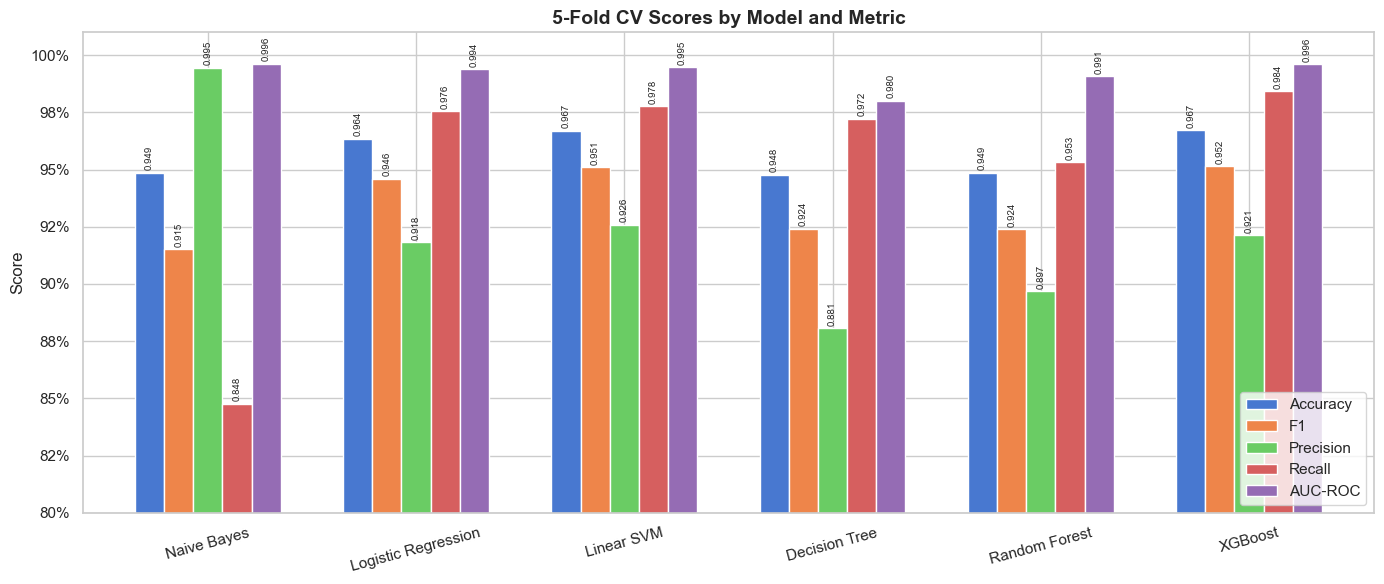

In [13]:
# ── Comparison plot ───────────────────────────────────────────────
metrics_to_plot = ['test_accuracy', 'test_f1', 'test_precision', 'test_recall', 'test_roc_auc']
metric_labels   = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC-ROC']

results_df = pd.DataFrame({
    name: {label: scores[m].mean() for m, label in zip(metrics_to_plot, metric_labels)}
    for name, scores in cv_scores.items()
}).T

print('Cross-Validation Results Summary:')
print(results_df.round(4).to_string())

ax = results_df.plot(kind='bar', figsize=(14, 6), edgecolor='white', width=0.7)
ax.set_title('5-Fold CV Scores by Model and Metric', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.80, 1.01)
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.001),
                ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
# plt.savefig('03_cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Hyperparameter Tuning — Best Model <a id='7'></a>

We tune the best-performing model using `GridSearchCV` (still on training data only).

In [14]:
# Tune Logistic Regression (typically best trade-off for text)
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True,
                              strip_accents='unicode', min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced',
                                 solver='lbfgs', random_state=SEED)),
])

param_grid = {
    'tfidf__ngram_range' : [(1, 1), (1, 2)],
    'tfidf__max_features': [20_000, 40_000],
    'clf__C'             : [0.1, 1.0, 5.0],
}

grid_search = GridSearchCV(
    lr_pipeline,
    param_grid,
    cv=skf,
    scoring='f1',          # optimise for F1 (handles imbalance)
    n_jobs=-1,
    verbose=1,
    refit=True,            # refit best model on full X_train
)

grid_search.fit(X_train, y_train)

print('\n✅ Best parameters:', grid_search.best_params_)
print(f'Best CV F1 Score : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best parameters: {'clf__C': 5.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 1)}
Best CV F1 Score : 0.9536


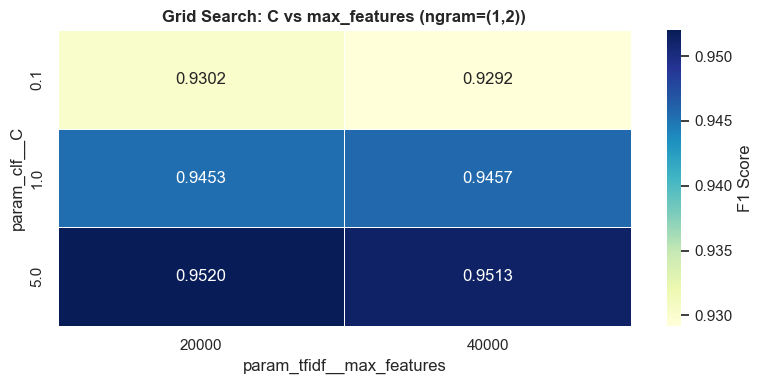

Best model stored as `best_model` ✅


In [15]:
# ── Grid search results heatmap ───────────────────────────────────
results_gs = pd.DataFrame(grid_search.cv_results_)
results_gs['ngram'] = results_gs['param_tfidf__ngram_range'].astype(str)

pivot = results_gs[results_gs['param_tfidf__ngram_range'] == (1, 2)].pivot_table(
    index='param_clf__C',
    columns='param_tfidf__max_features',
    values='mean_test_score'
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'F1 Score'})
plt.title('Grid Search: C vs max_features (ngram=(1,2))', fontweight='bold')
plt.tight_layout()
# plt.savefig('04_grid_search_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

best_model = grid_search.best_estimator_
print('Best model stored as `best_model` ✅')

---
## 8. Learning Curves — Overfitting Check <a id='8'></a>

Learning curves show whether the model suffers from **high variance (overfitting)** or **high bias (underfitting)**.

- **Overfitting**: large gap between train and validation curves
- **Underfitting**: both curves plateau at a low score
- **Good fit**: curves converge at a high score

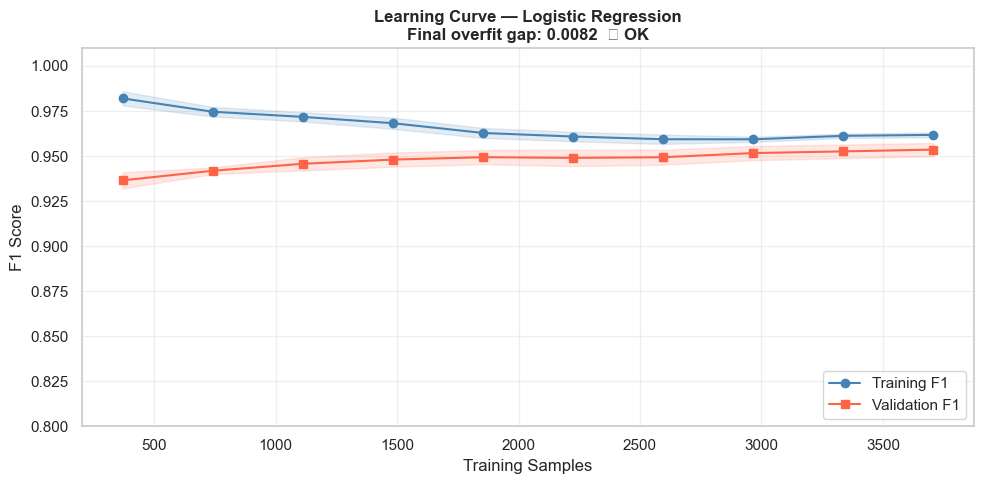


Final Train F1 : 0.9618
Final Val   F1 : 0.9536
Overfit Gap    : 0.0082


In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=skf,
    scoring='f1',
    train_sizes=np.linspace(0.10, 1.0, 10),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='tomato')

gap = (train_mean[-1] - val_mean[-1])
plt.title(f'Learning Curve — Logistic Regression\n'
          f'Final overfit gap: {gap:.4f}  {"⚠️ HIGH" if gap > 0.05 else "✅ OK"}',
          fontweight='bold')
plt.xlabel('Training Samples')
plt.ylabel('F1 Score')
plt.ylim(0.80, 1.01)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('05_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nFinal Train F1 : {train_mean[-1]:.4f}')
print(f'Final Val   F1 : {val_mean[-1]:.4f}')
print(f'Overfit Gap    : {gap:.4f}')

---
## 9. Final Evaluation on Hold-Out Test Set <a id='9'></a>

> 🔓 **The test set is unsealed here for the first time.**

In [17]:
# ── Predictions ───────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)

# LinearSVC doesn't have predict_proba natively — calibrate it
# (For LR, we get proba directly)
y_proba     = best_model.predict_proba(X_test)[:, 1]

print('='*60)
print('FINAL TEST SET RESULTS')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}')

FINAL TEST SET RESULTS
              precision    recall  f1-score   support

         Ham       0.99      0.96      0.98       781
        Spam       0.93      0.99      0.96       379

    accuracy                           0.97      1160
   macro avg       0.96      0.97      0.97      1160
weighted avg       0.97      0.97      0.97      1160

AUC-ROC : 0.9950


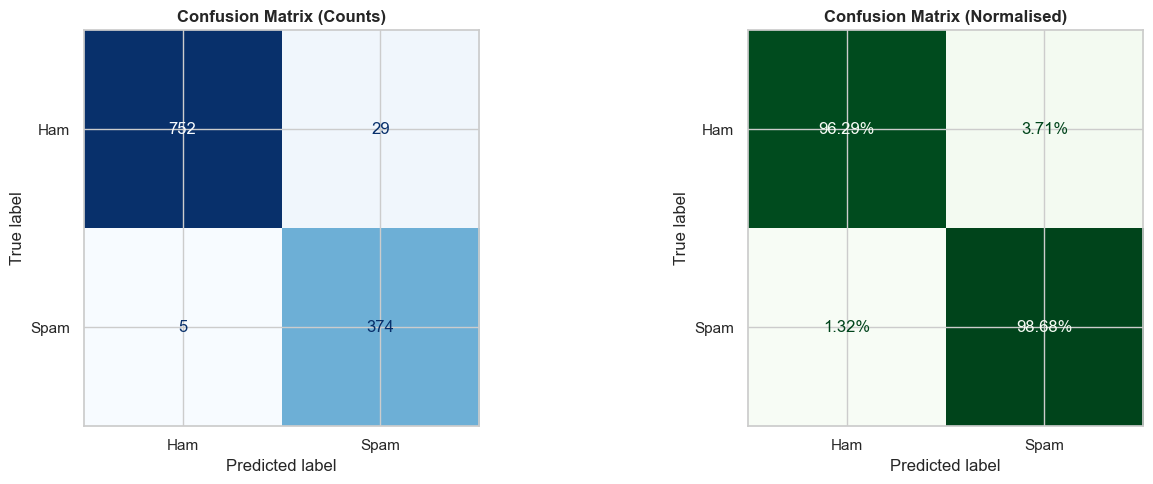

True Negatives  (Ham correctly classified)   : 752
True Positives  (Spam correctly classified)  : 374
False Positives (Ham misclassified as Spam)  : 29  ← False Alarm
False Negatives (Spam misclassified as Ham)  : 5  ← Missed Spam


In [18]:
# ── Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

# Normalised
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=['Ham', 'Spam'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

plt.tight_layout()
# plt.savefig('06_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Ham correctly classified)   : {tn}')
print(f'True Positives  (Spam correctly classified)  : {tp}')
print(f'False Positives (Ham misclassified as Spam)  : {fp}  ← False Alarm')
print(f'False Negatives (Spam misclassified as Ham)  : {fn}  ← Missed Spam')

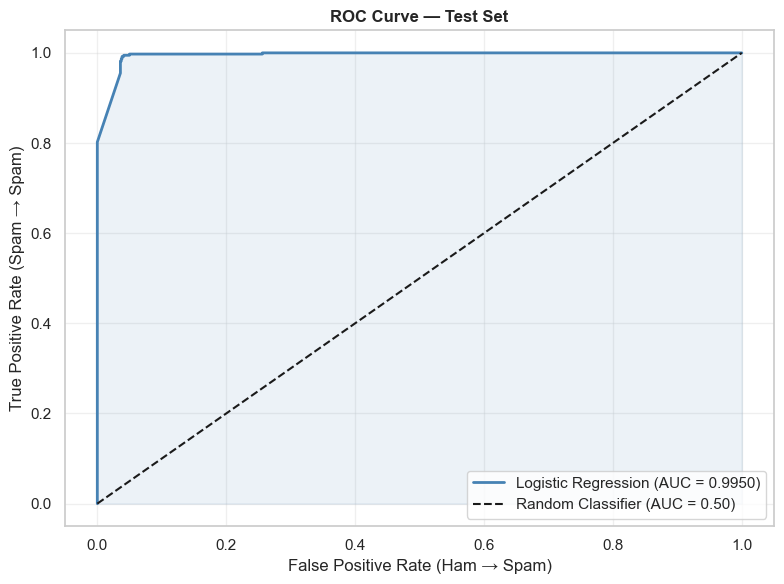

In [19]:
# ── ROC Curve ─────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.10, color='steelblue')
plt.xlabel('False Positive Rate (Ham → Spam)')
plt.ylabel('True Positive Rate (Spam → Spam)')
plt.title('ROC Curve — Test Set', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('07_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

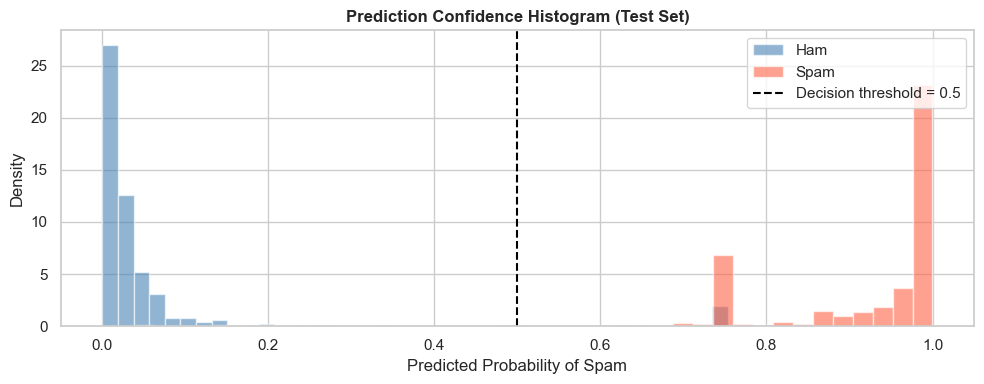

Well-separated peaks indicate the model is confident and well-calibrated.


In [20]:
# ── Probability calibration — confidence histogram ────────────────
plt.figure(figsize=(10, 4))
ham_proba  = y_proba[y_test == 0]
spam_proba = y_proba[y_test == 1]

plt.hist(ham_proba,  bins=40, alpha=0.6, color='steelblue',
         label='Ham',  edgecolor='white', density=True)
plt.hist(spam_proba, bins=40, alpha=0.6, color='tomato',
         label='Spam', edgecolor='white', density=True)
plt.axvline(0.5, color='black', linestyle='--', label='Decision threshold = 0.5')
plt.xlabel('Predicted Probability of Spam')
plt.ylabel('Density')
plt.title('Prediction Confidence Histogram (Test Set)', fontweight='bold')
plt.legend()
plt.tight_layout()
# plt.savefig('08_confidence_histogram.png', dpi=120, bbox_inches='tight')
plt.show()
print('Well-separated peaks indicate the model is confident and well-calibrated.')

---
## 10. Feature Importance — Top Spam / Ham Keywords <a id='10'></a>

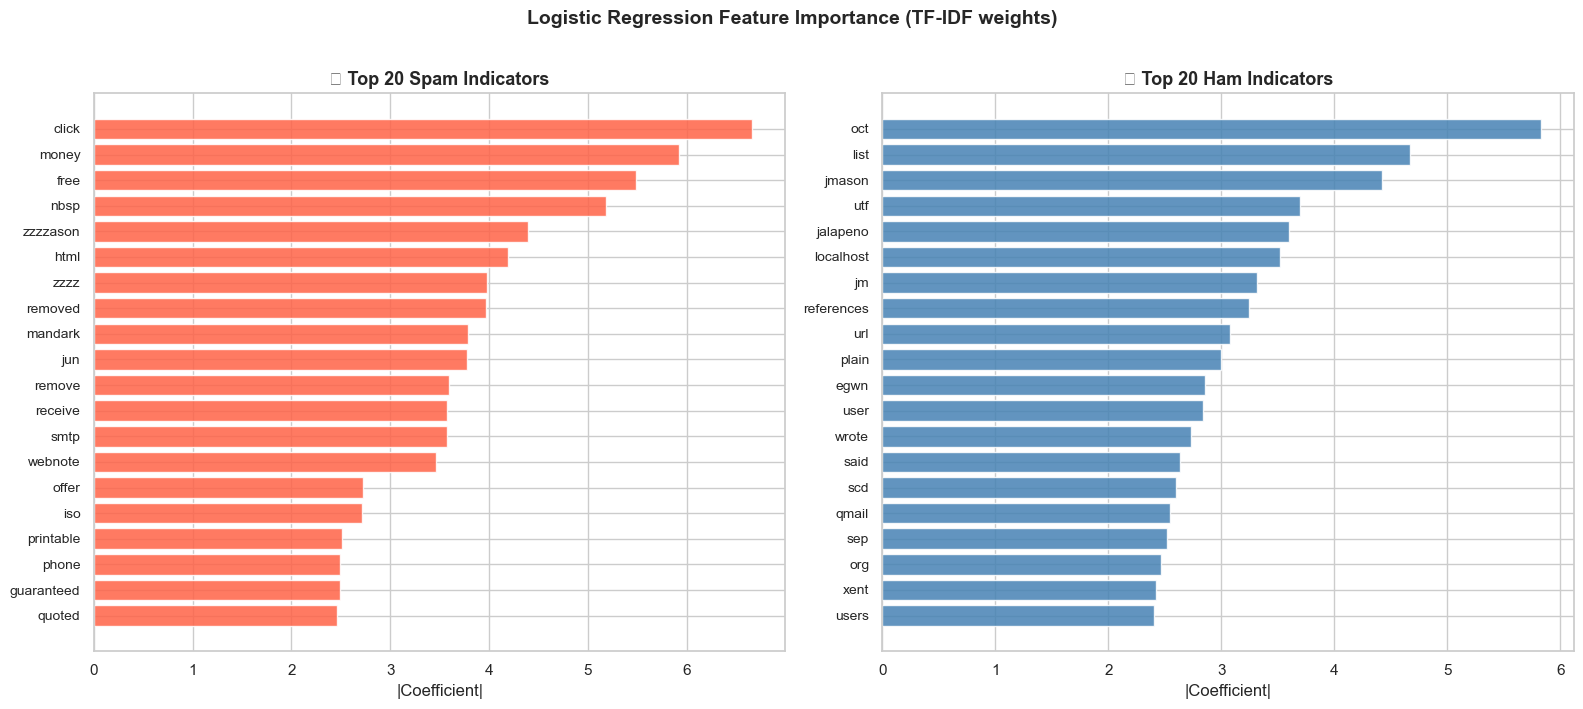

In [21]:
# Extract TF-IDF feature names and LR coefficients
tfidf_vectoriser = best_model.named_steps['tfidf']
lr_classifier    = best_model.named_steps['clf']

feature_names = np.array(tfidf_vectoriser.get_feature_names_out())
coefficients  = lr_classifier.coef_[0]

# Top 20 spam indicators (positive coef → spam)
top_spam_idx  = np.argsort(coefficients)[-20:][::-1]
top_ham_idx   = np.argsort(coefficients)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, idx, color, title in [
    (axes[0], top_spam_idx, 'tomato',    '🚨 Top 20 Spam Indicators'),
    (axes[1], top_ham_idx,  'steelblue', '✅ Top 20 Ham Indicators'),
]:
    words  = feature_names[idx]
    scores = np.abs(coefficients[idx])
    ax.barh(range(len(words)), scores[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=10)
    ax.set_xlabel('|Coefficient|')
    ax.set_title(title, fontweight='bold', fontsize=13)

plt.suptitle('Logistic Regression Feature Importance (TF-IDF weights)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('09_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()